In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from scipy.stats import spearmanr

In [ ]:
# ============================================================
# Read CRSP monthly stock data
# Full CRSP universe is used instead of only S&P 500.
# Reason:
# Behavioral effects may be stronger outside large-cap stocks.
# ============================================================

FILE_PATH = "all_20_24.csv"   # change to your file path

df = pd.read_csv(FILE_PATH)
df.columns = [c.upper() for c in df.columns]

print(df.shape)
print(df.head())

(1835494, 10)
   PERMNO        DATE  SHRCD TICKER DLRET    PRC     VOL        RET  SHROUT  \
0   10001  2004-12-31   11.0   EWST   NaN  6.900  1443.0   0.161616  2599.0   
1   10001  2005-01-31   11.0   EWST   NaN  6.620   515.0  -0.040580  2595.0   
2   10001  2005-02-28   11.0   EWST   NaN  6.321   726.0  -0.045166  2599.0   
3   10001  2005-03-31   11.0   EWST   NaN  7.110  4107.0   0.124822  2625.0   
4   10001  2005-04-29   11.0   EWST   NaN  6.579   527.0  -0.074684  2625.0   

        RETX  
0   0.161616  
1  -0.040580  
2  -0.045166  
3   0.124822  
4  -0.074684  


In [ ]:
# ============================================================
# Basic cleaning and type conversion
# ============================================================

df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

num_cols = ["RET", "DLRET", "RETX", "PRC", "SHROUT", "VOL", "SHRCD"]
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.sort_values(["PERMNO", "DATE"]).copy()

print(df[["PERMNO", "DATE"]].head())
print(df.shape)

   PERMNO       DATE
0   10001 2004-12-31
1   10001 2005-01-31
2   10001 2005-02-28
3   10001 2005-03-31
4   10001 2005-04-29
(1835494, 10)


In [ ]:
# ============================================================
# Combine RET and DLRET to reduce survivorship bias
#
# Why:
# If a stock delists, RET alone may miss the final economic return.
# We combine RET and DLRET so the final return better reflects the
# real investor experience.
# ============================================================

sp1 = df.copy()

mask_both = sp1["RET"].notna() & sp1["DLRET"].notna()
mask_ret_missing = sp1["RET"].isna() & sp1["DLRET"].notna()

sp1.loc[mask_both, "RET"] = (
    (1 + sp1.loc[mask_both, "RET"]) *
    (1 + sp1.loc[mask_both, "DLRET"]) - 1
)

sp1.loc[mask_ret_missing, "RET"] = sp1.loc[mask_ret_missing, "DLRET"]

print(sp1[["PERMNO", "DATE", "RET", "DLRET"]].head())

   PERMNO       DATE       RET  DLRET
0   10001 2004-12-31  0.161616    NaN
1   10001 2005-01-31 -0.040580    NaN
2   10001 2005-02-28 -0.045166    NaN
3   10001 2005-03-31  0.124822    NaN
4   10001 2005-04-29 -0.074684    NaN


In [ ]:
# ============================================================
# Apply standard filters
#
# 1) Keep only common shares: SHRCD in [10, 11]
# 2) Drop rows with missing RET after combining DLRET
# 3) Remove low-price stocks: PRC > 5
# 4) Keep only rows with positive volume and shares outstanding
#
# Why:
# These filters reduce microstructure noise and make the
# cross-sectional comparison more meaningful.
# ============================================================

before_n = len(sp1)

sp1 = sp1[sp1["SHRCD"].isin([10, 11])].copy()
sp1 = sp1.dropna(subset=["RET"]).copy()

sp1["PRC"] = sp1["PRC"].abs()
sp1 = sp1[sp1["PRC"] > 5].copy()

sp1 = sp1[(sp1["SHROUT"] > 0) & (sp1["VOL"] > 0)].copy()

if "DLRET" in sp1.columns:
    sp1 = sp1.drop(columns=["DLRET"])

print(f"Before filtering: {before_n:,}")
print(f"After basic filters: {len(sp1):,}")
print(f"Dropped: {before_n - len(sp1):,}")

Before filtering: 1,835,494
After basic filters: 747,141
Dropped: 1,088,353


In [ ]:
# ============================================================
# Construct market cap and turnover
#
# Note:
# In CRSP monthly, SHROUT is usually in thousands.
# ============================================================

sp1["MARKET_CAP"] = sp1["PRC"] * sp1["SHROUT"] * 1000
sp1["TURNOVER"] = sp1["VOL"] / (sp1["SHROUT"] * 1000)

sp1 = sp1[(sp1["MARKET_CAP"] > 0) & (sp1["TURNOVER"] >= 0)].copy()

# Mild clipping to stabilize extreme outliers
sp1["TURNOVER"] = sp1["TURNOVER"].clip(lower=0, upper=10)

print(sp1[["PERMNO", "DATE", "MARKET_CAP", "TURNOVER"]].head())

   PERMNO       DATE  MARKET_CAP  TURNOVER
0   10001 2004-12-31  17933100.0  0.000555
1   10001 2005-01-31  17178900.0  0.000198
2   10001 2005-02-28  16428279.0  0.000279
3   10001 2005-03-31  18663750.0  0.001565
4   10001 2005-04-29  17269875.0  0.000201


In [ ]:
# ============================================================
# Remove bottom 20% market cap each month
#
# Why:
# Very small stocks often add noisy extreme values and may dominate
# the cross-sectional results for the wrong reason.
# ============================================================

sp1["MC_RANK_PCT"] = sp1.groupby("DATE")["MARKET_CAP"].rank(pct=True)
sp1 = sp1[sp1["MC_RANK_PCT"] > 0.20].copy()

print("After removing bottom 20% market cap:")
print(sp1.shape)

After removing bottom 20% market cap:
(597809, 12)


In [ ]:
# ============================================================
# Construct abnormal turnover
#
# Main idea:
# We do not want "stocks that always trade a lot".
# We want "stocks that trade more than usual relative to their own history".
#
# ABTURN_Z_12 is the main behavioral variable.
# shift(1) is used to avoid look-ahead bias.
# ============================================================

sp1 = sp1.sort_values(["PERMNO", "DATE"]).copy()

LOOKBACK = 12
MIN_PERIODS = 6

g = sp1.groupby("PERMNO")["TURNOVER"]

sp1["TURNOVER_MEAN_12"] = (
    g.transform(lambda x: x.shift(1).rolling(LOOKBACK, min_periods=MIN_PERIODS).mean())
)

sp1["TURNOVER_STD_12"] = (
    g.transform(lambda x: x.shift(1).rolling(LOOKBACK, min_periods=MIN_PERIODS).std())
)

sp1["ABTURN_REL_12"] = sp1["TURNOVER"] / sp1["TURNOVER_MEAN_12"]

sp1["ABTURN_Z_12"] = (
    (sp1["TURNOVER"] - sp1["TURNOVER_MEAN_12"]) /
    sp1["TURNOVER_STD_12"]
)

sp1["ABTURN_REL_12"] = sp1["ABTURN_REL_12"].clip(lower=0, upper=10)
sp1["ABTURN_Z_12"] = sp1["ABTURN_Z_12"].clip(lower=-5, upper=5)

print(sp1[[
    "PERMNO", "DATE", "TURNOVER", "TURNOVER_MEAN_12",
    "TURNOVER_STD_12", "ABTURN_REL_12", "ABTURN_Z_12"
]].head(20))

     PERMNO       DATE  TURNOVER  TURNOVER_MEAN_12  TURNOVER_STD_12  \
153   10002 2004-12-31  0.000270               NaN              NaN   
154   10002 2005-01-31  0.000351               NaN              NaN   
155   10002 2005-02-28  0.000305               NaN              NaN   
156   10002 2005-03-31  0.000314               NaN              NaN   
157   10002 2005-04-29  0.000270               NaN              NaN   
158   10002 2005-05-31  0.000452               NaN              NaN   
159   10002 2005-06-30  0.000299          0.000327         0.000068   
160   10002 2005-07-29  0.000228          0.000323         0.000063   
161   10002 2005-08-31  0.000268          0.000311         0.000067   
162   10002 2005-09-30  0.000257          0.000306         0.000065   
163   10002 2005-10-31  0.000189          0.000301         0.000063   
164   10002 2005-11-30  0.000137          0.000291         0.000069   
165   10002 2005-12-30  0.000269          0.000278         0.000079   
166   

In [ ]:
# ============================================================
# Size neutralization
#
# What is being neutralized?
# We neutralize the SIGNAL, not returns.
# Specifically, we regress abnormal turnover on log market cap
# each month and use the residual as the final base signal.
#
# Why:
# Even abnormal turnover may still be related to firm size.
# ============================================================

sp1["LN_MKTCAP"] = np.log(sp1["MARKET_CAP"])

def neutralize_signal(subdf, signal_col="ABTURN_Z_12"):
    sub = subdf.dropna(subset=[signal_col, "LN_MKTCAP"]).copy()

    if len(sub) < 20:
        sub["SIGNAL_BASE"] = np.nan
        return sub

    X = sm.add_constant(sub[["LN_MKTCAP"]])
    y = sub[signal_col]

    try:
        model = sm.OLS(y, X).fit()
        sub["SIGNAL_BASE"] = model.resid
    except Exception:
        sub["SIGNAL_BASE"] = np.nan

    return sub

sp1 = (
    sp1.groupby("DATE", group_keys=False)
       .apply(neutralize_signal, signal_col="ABTURN_Z_12")
)

print(sp1[["PERMNO", "DATE", "ABTURN_Z_12", "LN_MKTCAP", "SIGNAL_BASE"]].head())

      PERMNO       DATE  ABTURN_Z_12  LN_MKTCAP  SIGNAL_BASE
159    10002 2005-06-30    -0.408872  19.195668    -1.229724
413    10026 2005-06-30     0.465328  19.978876    -0.180672
895    10032 2005-06-30    -1.136885  20.240354    -1.724509
2199   10085 2005-06-30    -0.772711  21.040735    -1.181649
2220   10092 2005-06-30    -1.181435  19.395167    -1.957748


/tmp/ipykernel_7747/1844565956.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(neutralize_signal, signal_col="ABTURN_Z_12")


In [ ]:
# ============================================================
# Size neutralization
#
# What is being neutralized?
# We neutralize the SIGNAL, not returns.
# Specifically, we regress abnormal turnover on log market cap
# each month and use the residual as the final base signal.
#
# Why:
# Even abnormal turnover may still be related to firm size.
# ============================================================

sp1["LN_MKTCAP"] = np.log(sp1["MARKET_CAP"])

def neutralize_signal(subdf, signal_col="ABTURN_Z_12"):
    sub = subdf.dropna(subset=[signal_col, "LN_MKTCAP"]).copy()

    if len(sub) < 20:
        sub["SIGNAL_BASE"] = np.nan
        return sub

    X = sm.add_constant(sub[["LN_MKTCAP"]])
    y = sub[signal_col]

    try:
        model = sm.OLS(y, X).fit()
        sub["SIGNAL_BASE"] = model.resid
    except Exception:
        sub["SIGNAL_BASE"] = np.nan

    return sub

sp1 = (
    sp1.groupby("DATE", group_keys=False)
       .apply(neutralize_signal, signal_col="ABTURN_Z_12")
)

print(sp1[["PERMNO", "DATE", "ABTURN_Z_12", "LN_MKTCAP", "SIGNAL_BASE"]].head())

      PERMNO       DATE  ABTURN_Z_12  LN_MKTCAP  SIGNAL_BASE
159    10002 2005-06-30    -0.408872  19.195668    -1.229724
413    10026 2005-06-30     0.465328  19.978876    -0.180672
895    10032 2005-06-30    -1.136885  20.240354    -1.724509
2199   10085 2005-06-30    -0.772711  21.040735    -1.181649
2220   10092 2005-06-30    -1.181435  19.395167    -1.957748


/tmp/ipykernel_7747/1844565956.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(neutralize_signal, signal_col="ABTURN_Z_12")


In [ ]:
# ============================================================
# Additional signal transformations
# ============================================================

# Demeaned version
sp1["SIGNAL_DEMEAN"] = (
    sp1["SIGNAL_BASE"] -
    sp1.groupby("DATE")["SIGNAL_BASE"].transform("mean")
)

# Rank version
sp1["SIGNAL_RANK"] = (
    sp1.groupby("DATE")["SIGNAL_BASE"].rank(pct=True)
)

print(sp1[["PERMNO", "DATE", "SIGNAL_BASE", "SIGNAL_DEMEAN", "SIGNAL_RANK"]].head())

      PERMNO       DATE  SIGNAL_BASE  SIGNAL_DEMEAN  SIGNAL_RANK
159    10002 2005-06-30    -1.229724      -1.229724     0.218605
413    10026 2005-06-30    -0.180672      -0.180672     0.553131
895    10032 2005-06-30    -1.724509      -1.724509     0.092665
2199   10085 2005-06-30    -1.181649      -1.181649     0.230769
2220   10092 2005-06-30    -1.957748      -1.957748     0.057961


In [ ]:
# ============================================================
# Create next-month return
#
# IMPORTANT:
# Do NOT align by exact date, because CRSP monthly dates are
# month-end trading dates, which may differ across months
# (e.g. 2007-06-29 vs 2007-05-31).
#
# Instead, align by monthly period.
# ============================================================

panel = sp1.copy()

# Convert each observation date into a monthly period
panel["MONTH_ID"] = panel["DATE"].dt.to_period("M")

future_ret = panel[["PERMNO", "MONTH_ID", "RET"]].copy()
future_ret["MONTH_SIGNAL"] = future_ret["MONTH_ID"] - 1
future_ret = future_ret.rename(columns={"RET": "RET_NEXT"})

panel = (
    panel.merge(
        future_ret[["PERMNO", "MONTH_SIGNAL", "RET_NEXT"]],
        left_on=["PERMNO", "MONTH_ID"],
        right_on=["PERMNO", "MONTH_SIGNAL"],
        how="left"
    )
    .drop(columns=["MONTH_SIGNAL"])
)

print(panel[["PERMNO", "DATE", "MONTH_ID", "SIGNAL_BASE", "SIGNAL_DEMEAN", "RET_NEXT"]].head(20))

    PERMNO       DATE MONTH_ID  SIGNAL_BASE  SIGNAL_DEMEAN  RET_NEXT
0    10002 2005-06-30  2005-06    -1.229724      -1.229724  0.079365
1    10026 2005-06-30  2005-06    -0.180672      -0.180672  0.123973
2    10032 2005-06-30  2005-06    -1.724509      -1.724509  0.014055
3    10085 2005-06-30  2005-06    -1.181649      -1.181649  0.036278
4    10092 2005-06-30  2005-06    -1.957748      -1.957748  0.011066
5    10104 2005-06-30  2005-06     0.564352       0.564352  0.028030
6    10107 2005-06-30  2005-06    -0.065189      -0.065189  0.030998
7    10108 2005-06-30  2005-06    -0.744668      -0.744668  0.020472
8    10119 2005-06-30  2005-06    -0.221550      -0.221550  0.027628
9    10137 2005-06-30  2005-06    -1.712133      -1.712133  0.130056
10   10138 2005-06-30  2005-06    -1.058931      -1.058931  0.059904
11   10143 2005-06-30  2005-06    -0.579366      -0.579366  0.010521
12   10145 2005-06-30  2005-06     0.155621       0.155621  0.072345
13   10147 2005-06-30  2005-06    

In [ ]:
# ============================================================
# Choose signal version
#
# Options:
# "SIGNAL_BASE"    -> size-neutralized abnormal turnover
# "SIGNAL_DEMEAN"  -> size-neutralized + cross-sectional demean
# "SIGNAL_RANK"    -> size-neutralized + rank transform
#
# Recommendation:
# Run these one by one and compare results.
# ============================================================

# SIGNAL_TO_TEST = "SIGNAL_BASE"
# SIGNAL_TO_TEST = "SIGNAL_DEMEAN"
SIGNAL_TO_TEST = "SIGNAL_RANK"

print(f"Testing signal: {SIGNAL_TO_TEST}")

Testing signal: SIGNAL_RANK


In [ ]:
# ============================================================
# IC functions
# ============================================================

def calc_monthly_ic(subdf, signal_col, ret_col="RET_NEXT"):
    sub = subdf.dropna(subset=[signal_col, ret_col]).copy()
    if len(sub) < 10:
        return np.nan
    return spearmanr(sub[signal_col], sub[ret_col]).correlation

def summarize_ic(ic_df, label="Signal"):
    mean_ic = ic_df["IC"].mean()
    std_ic = ic_df["IC"].std()
    n = ic_df["IC"].count()
    t_stat = mean_ic / (std_ic / np.sqrt(n)) if (std_ic is not None and std_ic > 0 and n > 1) else np.nan
    neg_ratio = (ic_df["IC"] < 0).mean()

    print(f"\n=== {label} IC Summary ===")
    print(f"Mean IC           : {mean_ic:.4f}")
    print(f"IC Std            : {std_ic:.4f}")
    print(f"t-stat            : {t_stat:.2f}")
    print(f"Negative IC ratio : {neg_ratio:.1%}")
    print(f"N months          : {n}")

    return pd.Series({
        "Mean_IC": mean_ic,
        "Std_IC": std_ic,
        "t_stat": t_stat,
        "Neg_Ratio": neg_ratio,
        "N_Months": n
    })

In [ ]:
# ============================================================
# Run monthly IC
# ============================================================

ic_df = (
    panel.groupby("DATE")
         .apply(calc_monthly_ic, signal_col=SIGNAL_TO_TEST, ret_col="RET_NEXT")
         .rename("IC")
         .reset_index()
)

ic_summary = summarize_ic(ic_df, label=SIGNAL_TO_TEST)
print(ic_summary)


=== SIGNAL_RANK IC Summary ===
Mean IC           : -0.0006
IC Std            : 0.0484
t-stat            : -0.20
Negative IC ratio : 48.5%
N months          : 234
Mean_IC       -0.000619
Std_IC         0.048426
t_stat        -0.195439
Neg_Ratio      0.485106
N_Months     234.000000
dtype: float64


/tmp/ipykernel_7747/801141798.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calc_monthly_ic, signal_col=SIGNAL_TO_TEST, ret_col="RET_NEXT")


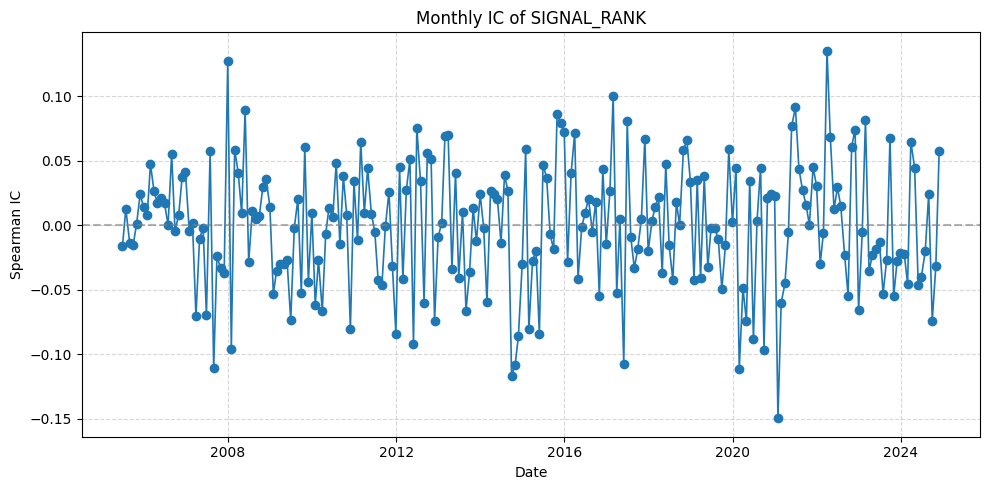

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ic_df["DATE"], ic_df["IC"], marker="o", linewidth=1.2)
plt.axhline(0, color="gray", linestyle="--", alpha=0.6)
plt.title(f"Monthly IC of {SIGNAL_TO_TEST}")
plt.xlabel("Date")
plt.ylabel("Spearman IC")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Assign deciles by chosen signal
# ============================================================

def assign_decile(subdf, signal_col, n=10):
    sub = subdf.dropna(subset=[signal_col]).copy()

    if len(sub) < n:
        sub["DECILE"] = np.nan
        return sub

    try:
        sub["DECILE"] = pd.qcut(
            sub[signal_col],
            q=n,
            labels=False,
            duplicates="drop"
        ) + 1
    except Exception:
        sub["DECILE"] = np.nan

    return sub

panel = (
    panel.groupby("DATE", group_keys=False)
         .apply(assign_decile, signal_col=SIGNAL_TO_TEST, n=10)
)

/tmp/ipykernel_7747/1300815218.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_decile, signal_col=SIGNAL_TO_TEST, n=10)


In [ ]:
# equal wit decile returns
def decile_return_ew(subdf):
    sub = subdf.dropna(subset=["DECILE", "RET_NEXT"]).copy()
    if sub.empty:
        return pd.Series(dtype=float)

    out = sub.groupby("DECILE")["RET_NEXT"].mean()
    out.index = [f"D{int(i)}" for i in out.index]
    return out

decile_ret_ew = (
    panel.groupby("DATE")
         .apply(decile_return_ew)
         .unstack()
         .sort_index()
)

for i in range(1, 11):
    col = f"D{i}"
    if col not in decile_ret_ew.columns:
        decile_ret_ew[col] = np.nan

decile_ret_ew = decile_ret_ew[[f"D{i}" for i in range(1, 11)]]
decile_ret_ew["LS"] = decile_ret_ew["D1"] - decile_ret_ew["D10"]

print(decile_ret_ew.head())

                  D1        D2        D3        D4        D5        D6  \
DATE                                                                     
2005-06-30  0.072843  0.056997  0.064110  0.059931  0.067520  0.061642   
2005-07-29 -0.023067 -0.013174 -0.008613 -0.003677 -0.010773 -0.006983   
2005-08-31  0.011069  0.006314  0.002037  0.011516  0.006273  0.002937   
2005-09-30 -0.018793 -0.030777 -0.016278 -0.018078 -0.029495 -0.031752   
2005-10-31  0.042858  0.052661  0.046693  0.038864  0.044230  0.057808   

                  D7        D8        D9       D10        LS  
DATE                                                          
2005-06-30  0.064997  0.056665  0.055208  0.064719  0.008125  
2005-07-29 -0.020294 -0.015685 -0.005532 -0.016548 -0.006519  
2005-08-31  0.003927  0.004529  0.014581 -0.001940  0.013009  
2005-09-30 -0.026091 -0.020792 -0.016005 -0.028928  0.010135  
2005-10-31  0.046783  0.044962  0.044344  0.045891 -0.003033  


/tmp/ipykernel_7747/3368776582.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(decile_return_ew)


In [ ]:
# value wit decile returns
def weighted_mean_ret(subdf, ret_col="RET_NEXT", w_col="MARKET_CAP"):
    sub = subdf.dropna(subset=[ret_col, w_col]).copy()
    if sub.empty:
        return np.nan

    w = sub[w_col]
    if w.sum() <= 0:
        return np.nan

    return np.average(sub[ret_col], weights=w)

def decile_return_vw(subdf):
    sub = subdf.dropna(subset=["DECILE", "RET_NEXT", "MARKET_CAP"]).copy()
    if sub.empty:
        return pd.Series(dtype=float)

    out = {}
    for d in sorted(sub["DECILE"].dropna().unique()):
        bucket = sub[sub["DECILE"] == d]
        out[f"D{int(d)}"] = weighted_mean_ret(bucket, ret_col="RET_NEXT", w_col="MARKET_CAP")
    return pd.Series(out)

decile_ret_vw = (
    panel.groupby("DATE")
         .apply(decile_return_vw)
         .unstack()
         .sort_index()
)

for i in range(1, 11):
    col = f"D{i}"
    if col not in decile_ret_vw.columns:
        decile_ret_vw[col] = np.nan

decile_ret_vw = decile_ret_vw[[f"D{i}" for i in range(1, 11)]]
decile_ret_vw["LS"] = decile_ret_vw["D1"] - decile_ret_vw["D10"]

print(decile_ret_vw.head())

                  D1        D2        D3        D4        D5        D6  \
DATE                                                                     
2005-06-30  0.036690  0.042975  0.070051  0.018188  0.060619  0.047996   
2005-07-29 -0.023581 -0.013780 -0.008078 -0.025340  0.006372  0.005451   
2005-08-31  0.004704  0.031887 -0.009007  0.001635  0.004109  0.013001   
2005-09-30 -0.013867 -0.026150 -0.003977  0.004877 -0.054645 -0.027770   
2005-10-31  0.047734  0.049283  0.042656  0.036650  0.043062  0.049271   

                  D7        D8        D9       D10        LS  
DATE                                                          
2005-06-30  0.044844  0.043838  0.020339  0.030696  0.005994  
2005-07-29 -0.007457 -0.010825 -0.013826 -0.005370 -0.018211  
2005-08-31 -0.007951  0.017375  0.020825 -0.006032  0.010736  
2005-09-30 -0.052334 -0.001031 -0.010634  0.000969 -0.014836  
2005-10-31  0.031336  0.031734  0.023154  0.024306  0.023428  


/tmp/ipykernel_7747/1653587401.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(decile_return_vw)


In [ ]:
# ============================================================
# Extreme-tail strategy
#
# We explicitly unstack the result so tail_ret_ew becomes
# a DataFrame with columns:
# BOTTOM10, TOP10, LONG_SHORT, SHORT_TOP10
# ============================================================

def assign_tail_group(subdf, signal_col):
    sub = subdf.dropna(subset=[signal_col]).copy()
    if len(sub) < 20:
        sub["TAIL_GROUP"] = np.nan
        return sub

    q10 = sub[signal_col].quantile(0.10)
    q90 = sub[signal_col].quantile(0.90)

    sub["TAIL_GROUP"] = "MID"
    sub.loc[sub[signal_col] <= q10, "TAIL_GROUP"] = "BOTTOM10"
    sub.loc[sub[signal_col] >= q90, "TAIL_GROUP"] = "TOP10"

    return sub

panel_tail = (
    panel.groupby("DATE", group_keys=False)
         .apply(assign_tail_group, signal_col=SIGNAL_TO_TEST)
)

def tail_return_ew(subdf):
    sub = subdf.dropna(subset=["TAIL_GROUP", "RET_NEXT"]).copy()
    if sub.empty:
        return pd.Series(dtype=float)

    grp = sub.groupby("TAIL_GROUP")["RET_NEXT"].mean()

    bottom10 = grp.get("BOTTOM10", np.nan)
    top10 = grp.get("TOP10", np.nan)

    return pd.Series({
        "BOTTOM10": bottom10,
        "TOP10": top10,
        "LONG_SHORT": bottom10 - top10,
        "SHORT_TOP10": -top10
    })

tail_ret_ew = (
    panel_tail.groupby("DATE")
              .apply(tail_return_ew)
)

# Safety check: if pandas returns a MultiIndex Series, unstack it
if isinstance(tail_ret_ew, pd.Series):
    tail_ret_ew = tail_ret_ew.unstack()

print(type(tail_ret_ew))
print(tail_ret_ew.head())
print(tail_ret_ew.columns)

/tmp/ipykernel_7747/3575524909.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(assign_tail_group, signal_col=SIGNAL_TO_TEST)


<class 'pandas.core.frame.DataFrame'>
            BOTTOM10  LONG_SHORT  SHORT_TOP10     TOP10
DATE                                                   
2005-06-30  0.072843    0.008125    -0.064719  0.064719
2005-07-29 -0.023067   -0.006519     0.016548 -0.016548
2005-08-31  0.011069    0.013009     0.001940 -0.001940
2005-09-30 -0.018793    0.010135     0.028928 -0.028928
2005-10-31  0.042858   -0.003033    -0.045891  0.045891
Index(['BOTTOM10', 'LONG_SHORT', 'SHORT_TOP10', 'TOP10'], dtype='object')


/tmp/ipykernel_7747/3575524909.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(tail_return_ew)


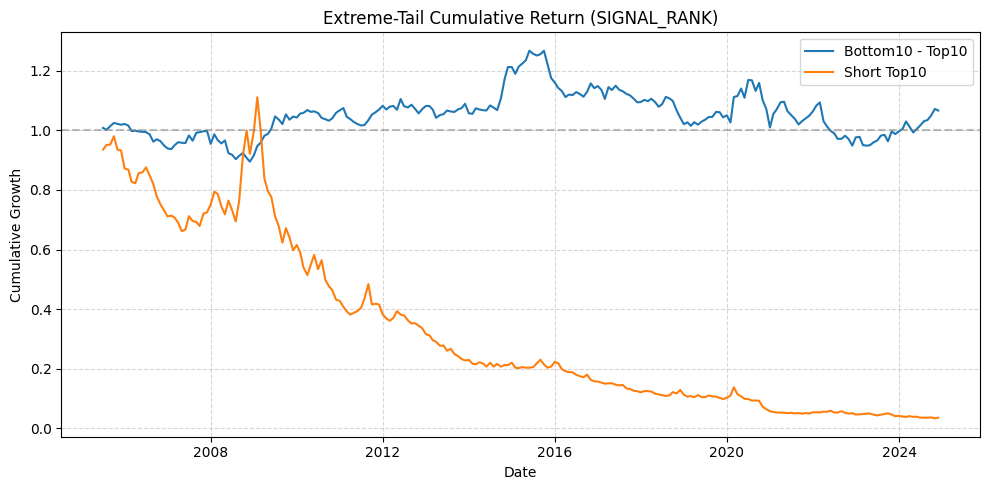

In [ ]:
cum_tail_ew = (1 + tail_ret_ew.fillna(0)).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(cum_tail_ew.index, cum_tail_ew["LONG_SHORT"], label="Bottom10 - Top10")
plt.plot(cum_tail_ew.index, cum_tail_ew["SHORT_TOP10"], label="Short Top10")
plt.axhline(1, color="gray", linestyle="--", alpha=0.5)
plt.title(f"Extreme-Tail Cumulative Return ({SIGNAL_TO_TEST})")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

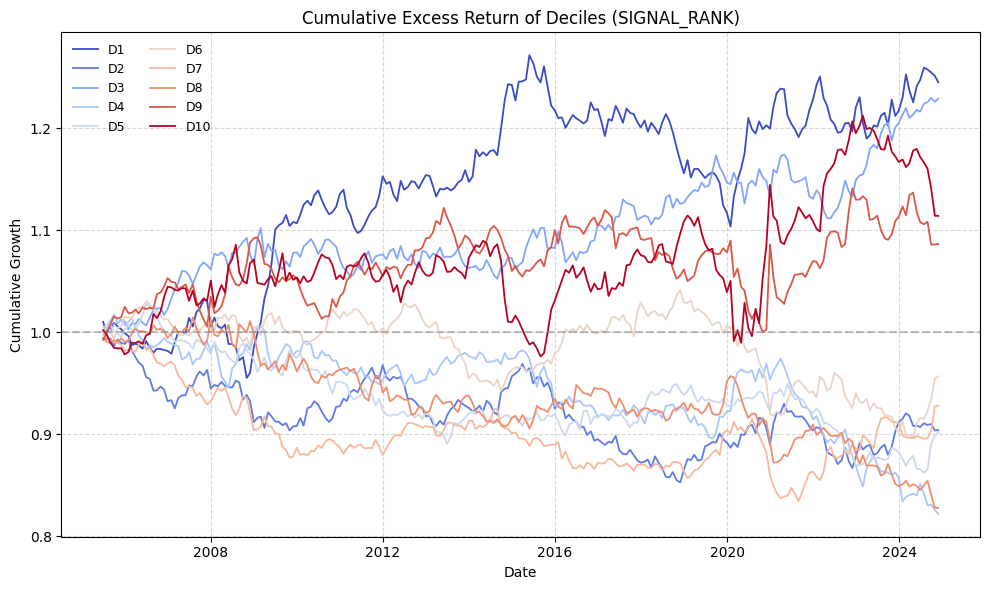

In [ ]:
# ============================================================
# Market-neutral excess return at portfolio level
#
# This is NOT signal neutralization.
# It is return-level adjustment.
# ============================================================

mkt_ret_ew = panel.groupby("DATE")["RET_NEXT"].mean().rename("MKT_RET")
decile_adj_ew = decile_ret_ew.merge(mkt_ret_ew, left_index=True, right_index=True, how="left")

for c in [f"D{i}" for i in range(1, 11)]:
    decile_adj_ew[c] = decile_adj_ew[c] - decile_adj_ew["MKT_RET"]

decile_adj_ew["LS"] = decile_adj_ew["D1"] - decile_adj_ew["D10"]

cum_excess_ew = (1 + decile_adj_ew.drop(columns=["MKT_RET"]).fillna(0)).cumprod()

plt.figure(figsize=(10, 6))
colors = cm.coolwarm(np.linspace(0, 1, 10))
for c, color in zip([f"D{i}" for i in range(1, 11)], colors):
    plt.plot(cum_excess_ew.index, cum_excess_ew[c], label=c, color=color, linewidth=1.3)

plt.title(f"Cumulative Excess Return of Deciles ({SIGNAL_TO_TEST})")
plt.xlabel("Date")
plt.ylabel("Cumulative Growth")
plt.axhline(1, color="gray", linestyle="--", alpha=0.5)
plt.legend(ncol=2, fontsize=9, frameon=False, loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# ic_df.to_csv(f"ic_{SIGNAL_TO_TEST}.csv", index=False)
# decile_ret_ew.to_csv(f"decile_ret_ew_{SIGNAL_TO_TEST}.csv")
# decile_ret_vw.to_csv(f"decile_ret_vw_{SIGNAL_TO_TEST}.csv")
# tail_ret_ew.to_csv(f"tail_ret_ew_{SIGNAL_TO_TEST}.csv")

# print("Saved outputs.")